In [1]:
def load_namespace():
    import sys
    sys.path.insert(1,f'/wsu/home/gy/gy40/gy4065/hm_jetscapeml_source')#WSU Grid
    sys.path.insert(1,'/content/drive/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v1
    sys.path.insert(1,'/content/drive/MyDrive/Projects/110_JetscapeMl/hm_jetscapeml_source')#Colab GDrive v2
    sys.path.insert(1,f'/mnt/g/My Drive/Projects/110_JetscapeMl/hm_jetscapeml_source')#wsl gdrive
    sys.path.insert(1,'G:\\My Drive\\Projects\\110_JetscapeMl\\hm_jetscapeml_source') #Windows GDrive
    sys.path.insert(1,'/home/arsalan/Projects/110_JetscapeML/hm_jetscapeml_source/') #office tower
    sys.path.insert(1,'/home/arsalan/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh from hmSrv3
    sys.path.insert(1,'/home/arsi/wsu-grid/hm_jetscapeml_source') #WSU Grid fssh from hmSrv1
    
load_namespace()

In [2]:
# Loading/Preparing Environment for simulation
from jet_ml.config import Config
#sim main
folds=1
epochs=50
dataset_size=1200000 #10800000 
# dataset_size=1800000 

#sim test
# folds=2
# epochs=2
# # dataset_size=250
# dataset_size=1000

classification_parameter="eloss"
q0_value=2.0
constant_parameter=f"q0_{q0_value}"

model_name=f"vgg16_net"
# model_name=f"mnist_net"

constant_parameter=None
if constant_parameter!=None:
    model_name=f"{model_name}_{constant_parameter}"

batch_size=128
server_name=f"batch_{batch_size}_"

cancel_rl_on_plateau=True
if cancel_rl_on_plateau==True:
    server_name=f"{server_name}no_rl_"

srv_hm3="hm_srv3_cpu_24_mem_32gb"
srv_a100="wsu_grid_a100_cpu_8_mem_150gb"
srv_v100="wsu_grid_v100_cpu_24_mem_256gb"
server_name=f"{server_name}{srv_hm3}"
# server_name=f"wsu_grid_v100_cpu_24_mem_256gb_batch_{batch_size}"
simulation_name=f"{classification_parameter}_{model_name}_{folds}_fold_{epochs}_epoch_{int(dataset_size/1000)}k_dataset_size_{server_name}"

config=Config(simulation_name=simulation_name)
config.__str__()

2024-11-21 18:57:42.786605: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-21 18:57:42.793995: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-21 18:57:42.802659: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-21 18:57:42.805247: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-21 18:57:42.811792: I tensorflow/core/platform/cpu_feature_guar

Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.
Directory /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb already exists.


2024-11-21 18:57:43.832644: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


'Project Root: /home/arsalan/wsu-grid/hm_jetscapeml_source\nData Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/data\nModels Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models\nReports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports\nFigures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures\nSimulation Models Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/models/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Reports Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nSimulation Figures Directory: /home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb\nEnvironment Details:\n  TensorFlow Version: 2.17.0\n  Keras Version: 3.5.0\n  Python Version: 3.12.5 | packaged by conda-for

Defining a class that gets training history dict and return a history object just like the way keras would return

In [3]:
class MockHistory:
    def __init__(self, history):
        self.history = history


Reading single training history csv file

In [ ]:
#loading training history from csv file
import pandas as pd
# Load the CSV file into a DataFrame
history_df = pd.read_csv('~/wsu-grid/hm_jetscapeml_data/all_simulations/simulation-results-deep-model-cnn-01-1200K-config-01-epoch-{epochs}}/hm_jetscape_ml_model_history.csv')

# Display the first few rows of the data
print(history_df.head())

# Convert the DataFrame to a dictionary format similar to history.history
history_dict = history_df.to_dict(orient='list')
# Create a mock history object
history = MockHistory(history_dict)

a method to Plot a single training history file

In [ ]:
import matplotlib.pyplot as plt
def plot_training_history(history, fold=None,x_tick=5,loss_y_scale=None):
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size
    })
    import os
    from jet_ml.config import Config
    """
    Plot training and validation accuracy and loss values and save the plot with high resolution.

    Parameters:
    - history (tf.keras.callbacks.History): History object containing training/validation metrics.
    - simulation_path (str): Path to save the plot.
    - x_tick (int) steps in x axis (optional: the default value is 5).

    Returns:
    - file_path (str): File path of the saved plot.
    """
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        x_axis_length=len(history.history.get('accuracy', []))+1
        plt.plot(history.history['accuracy'])
    # if 'sparse_categorical_accuracy' in history.history:
    #     x_axis_length=len(history.history.get('sparse_categorical_accuracy', []))+1
    #     plt.plot(history.history['sparse_categorical_accuracy'])
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'])
    # if 'val_sparse_categorical_accuracy' in history.history:
    #     plt.plot(history.history['val_sparse_categorical_accuracy'])
    
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')
    # Set ticks on the epoch axis to display only integer values
    plt.xticks(range(0, x_axis_length, x_tick))

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    if loss_y_scale!=None:
        plt.yscale(loss_y_scale)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Set ticks on the epoch axis to display only integer values
    plt.xticks(range(0, x_axis_length, x_tick))

    # Adjust layout and show the plot
    plt.tight_layout()

    # Save the plot with high resolution (300 dpi)
    file_name = 'accuracy_loss'
    if fold!=None:
        file_name=f"{file_name}_fold_{fold}"
    file_name=f"{file_name}.png"
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR,file_name)
    # plt.savefig(file_name, dpi=300)
    plt.savefig(file_name)
    plt.show()
    plt.close()

    return file_name

In [ ]:
# from jet_ml.evaluation import plot_training_history
plot_training_history(history=history,fold=None,loss_y_scale='log')

reading 9 training history for eloss classification with vgg16

In [4]:
import pandas as pd
model_name="deep-model-cnn-01"
# model_name="nn-mnist"
# Base path to the directory containing the history files
base_path = f'~/wsu-grid/hm_jetscapeml_data/all_simulations/simulation-results-{model_name}-1200K-config-'

# List to hold history dictionaries
histories = []

# Loop to load each file
for i in range(1, 10):
    file_path = f"{base_path}{i:02d}-epoch-{epochs}/hm_jetscape_ml_model_history.csv"
    # Load each CSV file into a DataFrame
    history_df = pd.read_csv(file_path)
    # Convert the DataFrame to a dictionary format similar to history.history
    history_dict = history_df.to_dict(orient='list')
    # Create a mock history object
    history = MockHistory(history_dict)
    # Append the dictionary to the list
    histories.append(history)

# Display a sample from one of the loaded histories to verify
print(histories[0])  # Print the first history dictionary

In [5]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config
from cycler import cycler

def plot_multiple_histories_with_row_col_title(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy', marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot
        ax2 = ax1.twinx()  # Share x-axis
        ax2.set_prop_cycle(cycler('color', plt.rcParams['axes.prop_cycle'].by_key()['color'][2:]))
        ax2.plot(history.history.get('loss', []), label='Train Loss', marker='^', linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss', marker='d', linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')
        

        # Place the legends outside the plot to the right (center right)
        ax1.legend(loc='center left', bbox_to_anchor=accuracy_bbox_to_anchor, fontsize=10, frameon=True, ncol=1)
        ax2.legend(loc='center left', bbox_to_anchor=loss_bbox_to_anchor, fontsize=10, frameon=True, ncol=1)

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.77 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    # Adjust layout to fit titles and avoid overlap
    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Ensure room for the legends outside

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid.pdf')
    plt.savefig(file_name, dpi=300, bbox_inches='tight')  # Include legends outside the plot
    plt.show()
    plt.close()

    return file_name


In [6]:
import matplotlib.pyplot as plt
import os
from jet_ml.config import Config
from cycler import cycler

def plot_multiple_histories_with_row_col_title_bw(histories, row_titles=None, col_titles=None, x_tick=5, loss_y_scale=None):
    """
    Plot multiple training and validation accuracy and loss plots in a 3x3 grid with row and column titles.

    Parameters:
    - histories (list): List of tf.keras.callbacks.History objects containing training/validation metrics.
    - row_titles (list): Titles for each row in the grid.
    - col_titles (list): Titles for each column in the grid.
    - x_tick (int): Steps in x-axis (default is 5).
    - loss_y_scale (str): Scaling for loss y-axis, e.g., 'log' for logarithmic scale.
    """
    # Increase font sizes globally
    plt.rcParams.update({
        'axes.titlesize': 18,       # Title font size
        'axes.labelsize': 14,       # Axis label font size
        'xtick.labelsize': 12,      # X-tick font size
        'ytick.labelsize': 12,      # Y-tick font size,
    })

    fig, axs = plt.subplots(3, 3, figsize=(18, 18))
    axs = axs.flatten()  # Flatten to easily iterate through subplots

    # Plot each history in a 3x3 grid
    for i, history in enumerate(histories):
        if i >= 9:
            break  # Stop if more than 9 histories

        # Accuracy plot
        ax1 = axs[i]
        x_axis_length = len(history.history.get('accuracy', [])) + 1
        ax1.plot(history.history.get('accuracy', []), label='Train Accuracy',color='black',  marker='o', linestyle='-', markersize=5)
        ax1.plot(history.history.get('val_accuracy', []), label='Val Accuracy', color='black', marker='s', linestyle='--', markersize=5)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.set_xticks(range(0, x_axis_length, x_tick))

        # Loss plot
        ax2 = ax1.twinx()  # Share x-axis
        # ax2.set_prop_cycle(cycler('color', plt.rcParams['axes.prop_cycle'].by_key()['color'][2:]))
        ax2.plot(history.history.get('loss', []), label='Train Loss',color='gray',  marker='^', linestyle='-', markersize=4)
        ax2.plot(history.history.get('val_loss', []), label='Val Loss',color='gray',  marker='d', linestyle='--', markersize=4)
        if loss_y_scale:
            ax2.set_yscale(loss_y_scale)
        ax2.set_ylabel('Loss')

        # Place the legends outside the plot to the right (center right)
        ax1.legend(loc='center left', bbox_to_anchor=accuracy_bbox_to_anchor, fontsize=10, frameon=True, ncol=1)
        ax2.legend(loc='center left', bbox_to_anchor=loss_bbox_to_anchor, fontsize=10, frameon=True, ncol=1)

    # Add column titles
    if col_titles:
        for col, title in enumerate(col_titles):
            fig.text(0.25 + col * 0.25, 0.92, title, ha='center', va='center', fontsize=20)

    # Add row titles
    if row_titles:
        for row, title in enumerate(row_titles):
            fig.text(0.08, 0.77 - row * 0.25, title, ha='center', va='center', rotation='vertical', fontsize=20)

    # Adjust layout to fit titles and avoid overlap
    plt.tight_layout(rect=[0.1, 0.1, 0.9, 0.9])  # Ensure room for the legends outside

    # Save the plot with high resolution (300 dpi)
    file_name = os.path.join(Config().SIMULATION_FIGURES_DIR, 'accuracy_loss_grid_bw.pdf')
    plt.savefig(file_name, dpi=300, bbox_inches='tight')  # Include legends outside the plot
    plt.show()
    plt.close()

    return file_name


In [7]:
row_titles = [
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=1.5$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2$",
    r"Mat: $Q_0=1$, Mat-LBT: $Q_0=2.5$"
]
col_titles = [r"$\alpha_s = 0.2$", r"$\alpha_s = 0.3$", r"$\alpha_s = 0.4$"]

In [8]:
if model_name=="deep-model-cnn-01":     
    accuracy_bbox_to_anchor=(0.5, 0.45)
    loss_bbox_to_anchor=(0.6, 0.3)
elif model_name=="nn-mnist":
    accuracy_bbox_to_anchor=(0.4, 0.45)
    loss_bbox_to_anchor=(0.5, 0.3)

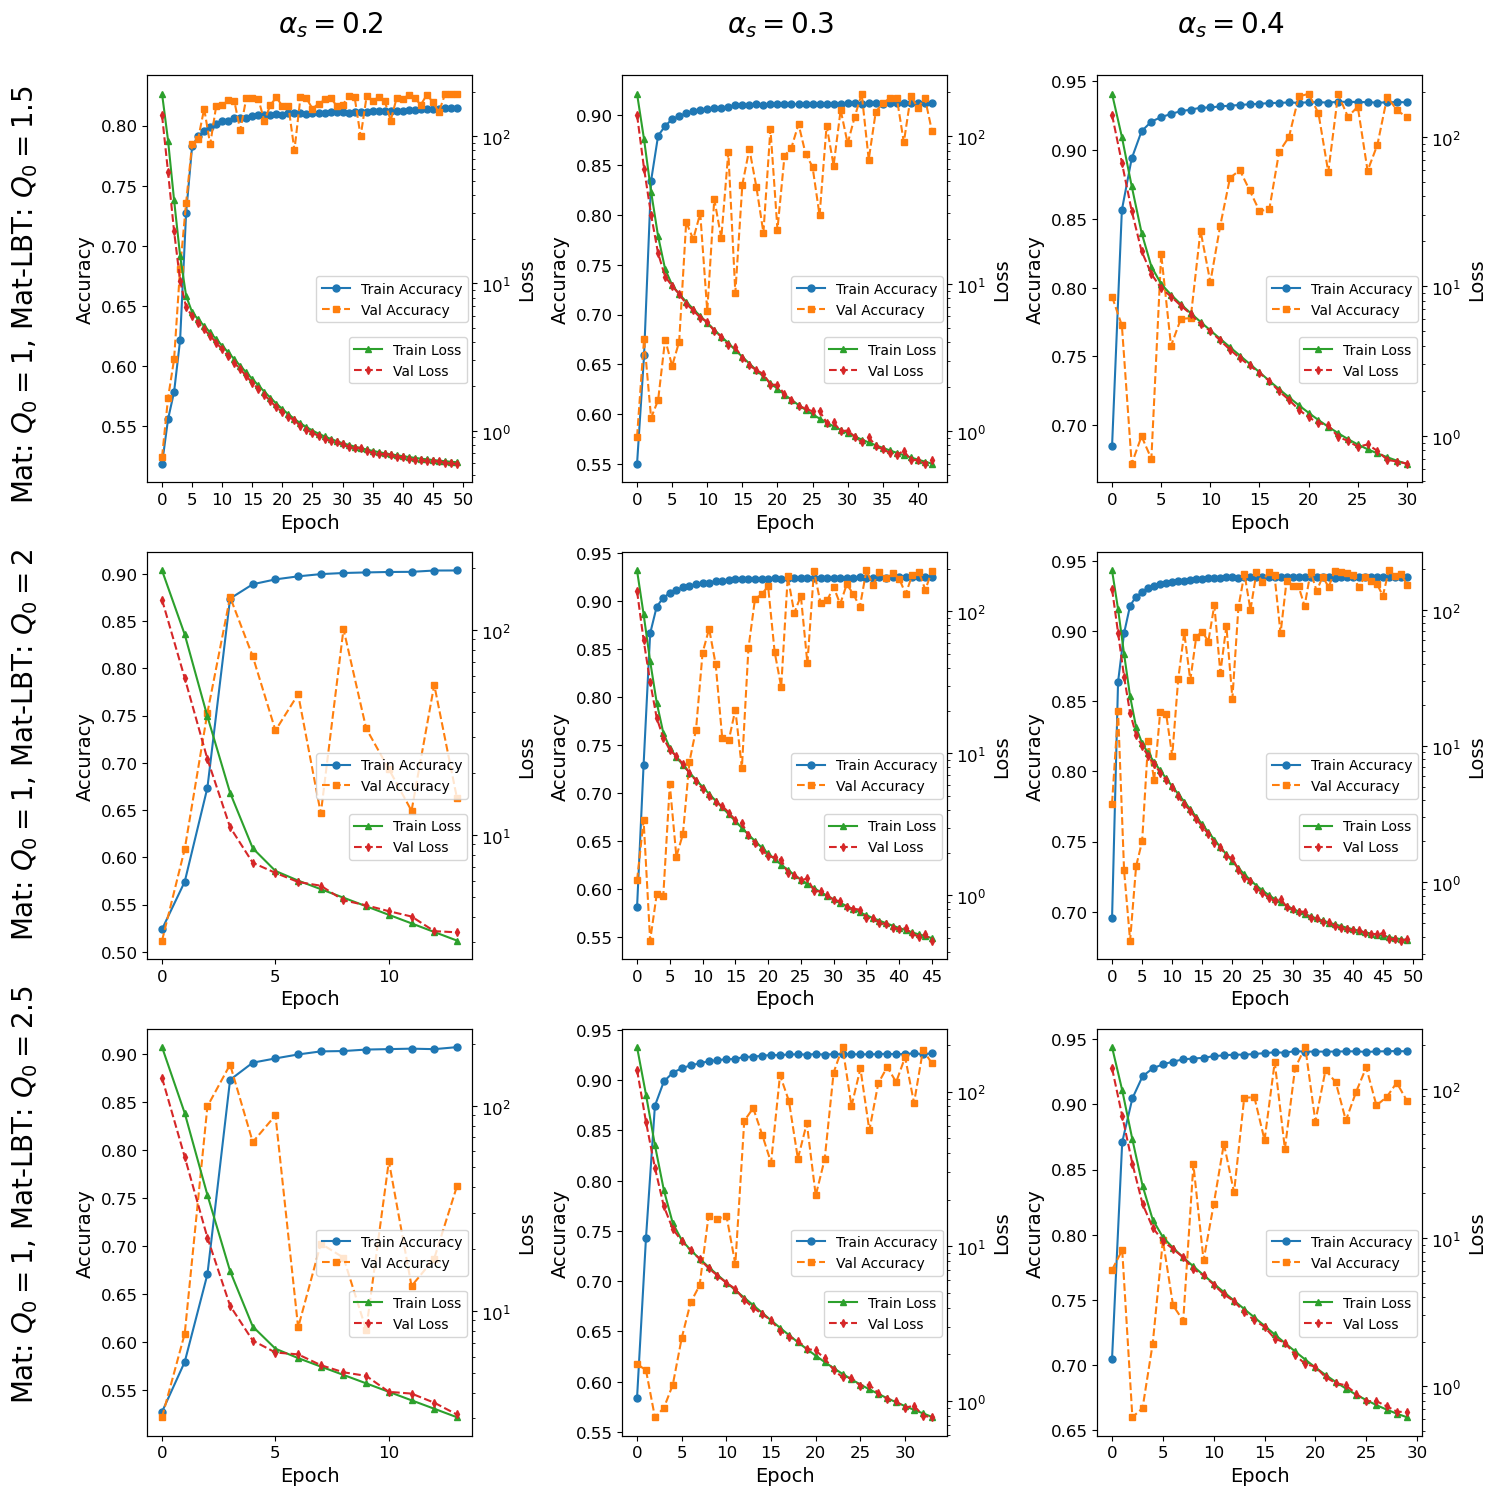

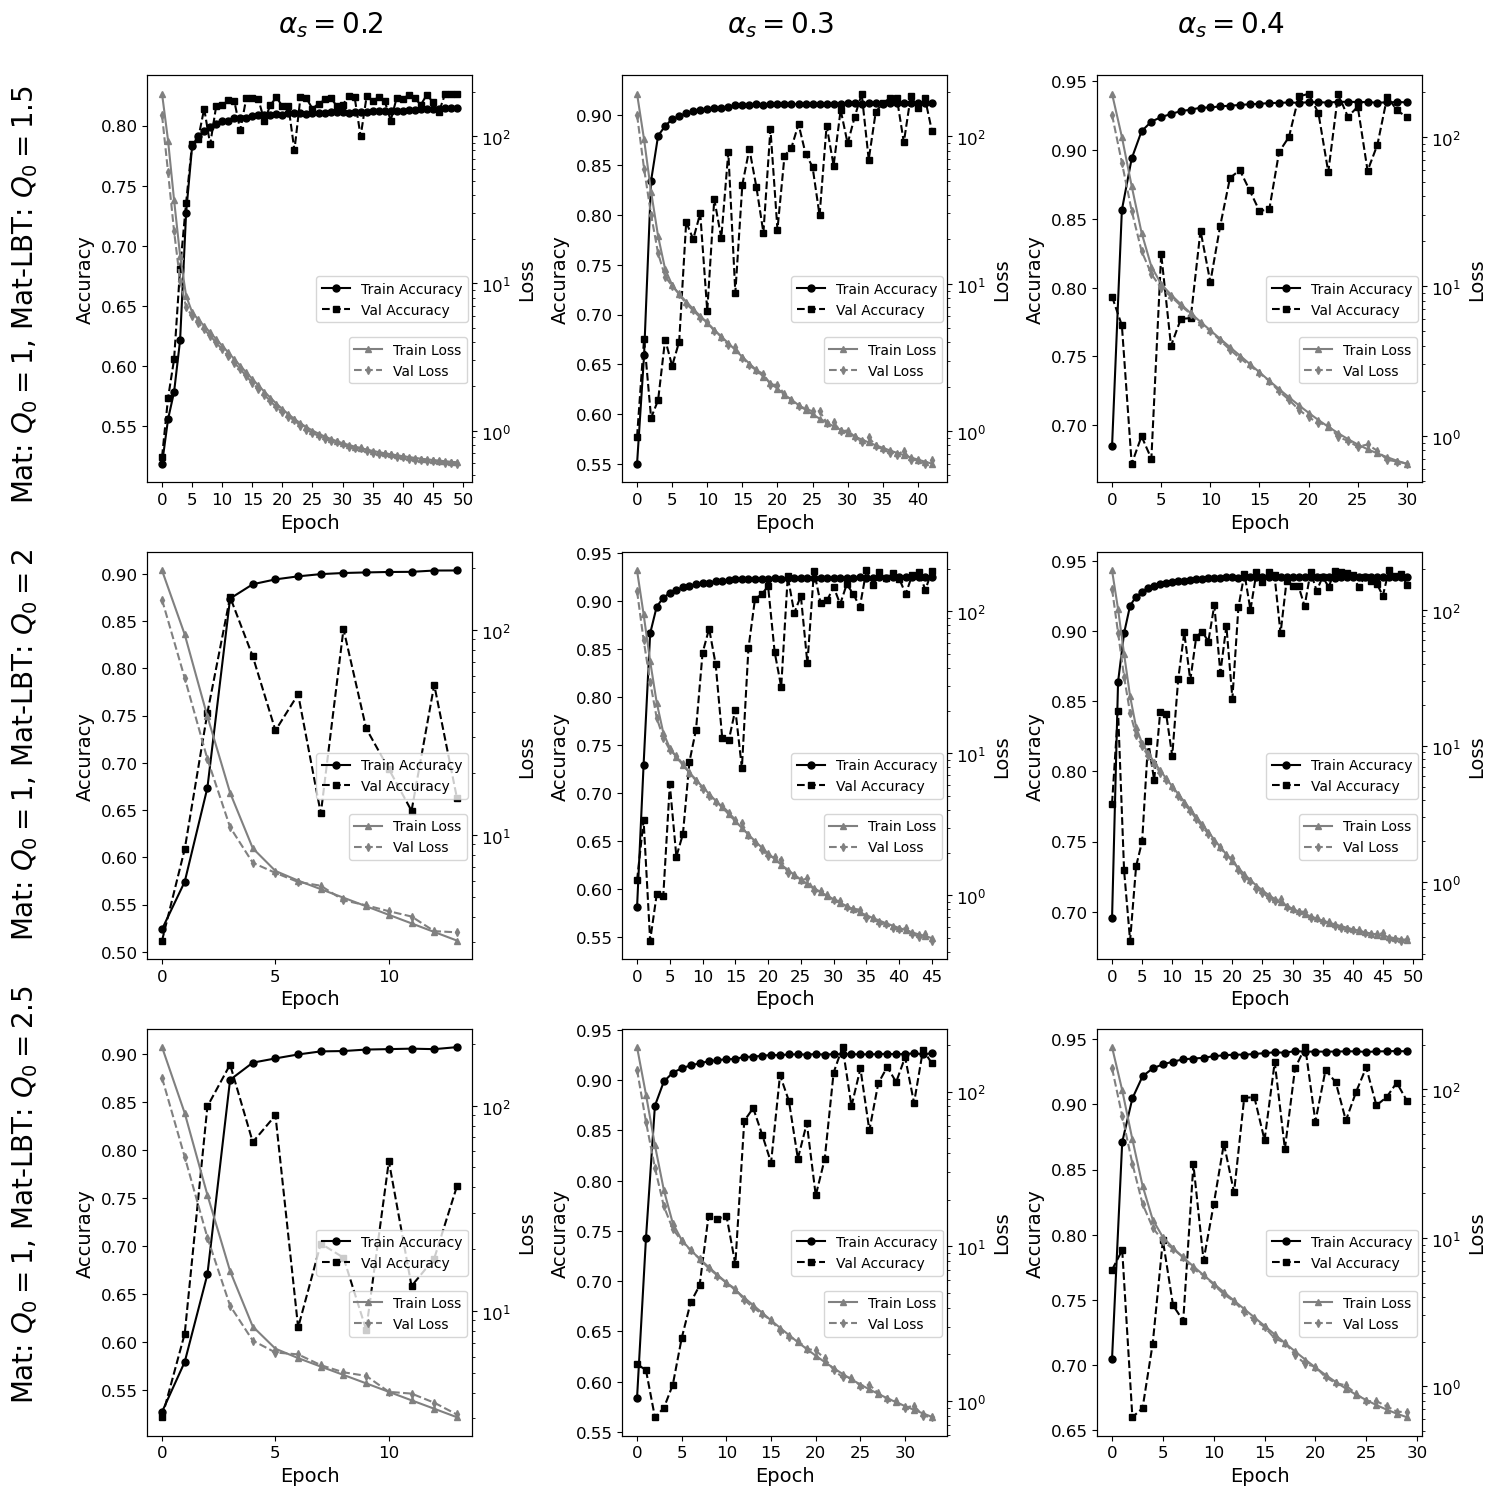

'/home/arsalan/wsu-grid/hm_jetscapeml_source/reports/figures/eloss_vgg16_net_1_fold_50_epoch_1200k_dataset_size_batch_128_no_rl_hm_srv3_cpu_24_mem_32gb/accuracy_loss_grid_bw.pdf'

In [9]:
plot_multiple_histories_with_row_col_title (histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')
plot_multiple_histories_with_row_col_title_bw(histories=histories, row_titles=row_titles, col_titles=col_titles, loss_y_scale='log')